In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from scipy.differentiate import derivative

sns.set_style('darkgrid')

In [2]:
# Taken directly from lecture 7 code

def GBM_paths(S0, sigma, t, r, mu, n_sims, n_steps):
    """Simulates stock paths as geometric Brownian Motions
    Inputs:
    S0 (float): Underlying stock price at time 0
    sigma (float): Yearly volatility
    t (float): Time to expiration (years)
    r (float): Risk-free interest rate
    mu (float): Drift of log-returns
    n_sims (int): Number of simulated paths
    n_steps (int): Number of steps in each simulated path, each step interval has length t/n_steps
    
    Return (np.array): Array of stock paths
    """
    
    dt = t/n_steps
    noise = np.random.normal(loc = 0, scale = 1, size = (n_sims, n_steps))
    log_returns = (mu+r-sigma**2*(0.5))*dt + sigma*np.sqrt(dt)*noise
    exponent = np.cumsum(log_returns, axis = 1)
    paths = S0*np.exp(exponent)
    paths_with_start = np.insert(paths, 0, S0, axis = 1)

    return paths_with_start

def bs_call(S0, K, sigma, t, r):
    '''
    Black-Scholes Call Option formula
    
    Inputs:
    S0 (float): Stock price at time 0
    K (float): Strike Price
    sigma: Yearly volatility
    t: Time to expiration (years)
    r: Risk-free Interest rate
    
    
    Return:
    Black-Scholes value of call option (float)
    '''
    
    d1 = (np.log(S0/K) + (r + (0.5)*sigma**2)*t)/(sigma*np.sqrt(t))
    
    d2 = d1 - sigma*np.sqrt(t)
    
    
    call_value = S0*norm.cdf(d1) - K*np.exp(-r*t)*norm.cdf(d2)
    
    
    return call_value

def bs_call_delta(S0, K, sigma, t, r):
    '''Black-Scholes Delta of Call Option
    
    Inputs:
    S0 (float): Stock price at time 0
    K (float): Strike Price
    sigma: Yearly volatility
    t: Time to expiration (years)
    r: Risk-free Interest rate
    
    
    Return:
    Black-Scholes rate of change of call option with respect to S_0
    
    '''
    
    d1 = (np.log(S0/K) + (r + (0.5)*sigma**2)*t)/(sigma*np.sqrt(t))
    
    
    return norm.cdf(d1)


def bs_vega(S0, K, sigma, t, r):
    '''Black-Scholes vega of Call & Put Options
    
    Inputs:
    S0 (float): Stock price at time 0
    K (float): Strike Price
    sigma: Yearly volatility
    t: Time to expiration (years)
    r: Risk-free Interest rate
    
    
    Return:
    Black-Scholes rate of change of call & put option with respect to sigma
    
    '''
    
    d1 = (np.log(S0/K) + (r + (0.5)*sigma**2)*t)/(sigma*np.sqrt(t))
    
    
    return S0*norm.pdf(d1)*np.sqrt(t)

def GBM_point(S0, sigma, t, r, mu):
    """Gives a single sample from geometric brownian motion at time t
    Inputs:
    S0 (float): Stock price at time t=0
    sigma (float): Yearly volatility
    t (float): Time in years
    r (float): Risk-free interest rate
    mu (float): Drift of log-returns
    """
    noise = np.random.normal(loc = 0, scale = 1)
    log_returns = (mu+r-sigma**2*(0.5))*t + sigma*np.sqrt(t)*noise
    endval = S0 * np.exp(log_returns)
    return endval

In [22]:
# Call barrier option value distribution under Black-Scholes
# Monitored at all steps

def bs_call_barrier(S0, K, H, sigma, t, r, mu, n_sims, n_steps, up=True, out=True):
    stock_paths = GBM_paths(S0, sigma, t, r, mu, n_sims, n_steps)
    if up:
        breached = stock_paths >= H
    else:
        breached = stock_paths <= H
    which_paths_breached = np.any(breached, axis=1)
    if out:
        which_paths_good = ~which_paths_breached
    else:
        which_paths_good = which_paths_breached
    naive_stock_values = stock_paths[:, -1]
    naive_call_values = np.maximum(naive_stock_values - K, 0)
    call_values = np.where(which_paths_good, naive_call_values, 0)
    discounted_call_values = np.exp(-r*t)*call_values
    return discounted_call_values

In [4]:
def d1(S0, K, sigma, t, r):
    return (np.log(S0/K) + (r + (0.5)*sigma**2)*t)/(sigma*np.sqrt(t))
def d2(S0, K, sigma, t, r):
    return d1(S0, K, r, sigma, t) - sigma*np.sqrt(t)

def bs_call_di_hull(S0, K, H, sigma, t, r):
    '''
    Black-Scholes Down-and-In Barrier Call Option formula
    
    Inputs:
    S0 (float): Stock price at time 0
    K (float): Strike Price
    H (float): Barrier Price
    sigma: Yearly volatility
    t: Time to expiration (years)
    r: Risk-free Interest rate
    
    
    Return:
    Black-Scholes value of d/i call option (float)
    '''
    l = (r + (0.5)*sigma**2)/sigma**2
    y = np.log(H**2 / (S0*K))/(sigma * np.sqrt(t)) + l * sigma * np.sqrt(t)
    t1 = S0*(H/S0)**(2*l)*norm.cdf(y)
    t2 = -K*np.exp(-r*t)*(H/S0)**(2*l-2)*norm.cdf(y-sigma*np.sqrt(t))
    return t1+t2

def bs_call_di_hull_delta(S0, K, H, sigma, t, r):
    '''
    Black-Scholes Down-and-In Barrier Call Option delta formula
    
    Inputs:
    S0 (float): Stock price at time 0
    K (float): Strike Price
    H (float): Barrier Price
    sigma: Yearly volatility
    t: Time to expiration (years)
    r: Risk-free Interest rate
    
    
    Return:
    Black-Scholes delta for d/i call option (float)
    '''
    l = (r + (0.5)*sigma**2)/sigma**2
    sdiv = sigma * np.sqrt(t)
    y = np.log(H**2 / (S0*K))/(sdiv) + l * sdiv
    pdv_t1 = (H/S0)**(2*l) * ((1-2*l)*norm.cdf(y) - norm.pdf(y)/(sdiv))
    pdv_t2 = -K*np.exp(-r*t)*(H/S0)**(2*l-2)*(1/S0)*((2-2*l)*norm.cdf(y-sdiv) - norm.pdf(y-sdiv)/(sdiv))
    return pdv_t1 + pdv_t2

In [23]:
S0 = 250
K = 250
H = 220
sigma = .4
mu = 0
t = 1
r = .035
nsims = 32000
nsteps = [10, 100, 252, 1000, 4000]

bs_call_di_mc_dists = {
    steps: bs_call_barrier(S0, K, H, sigma, t, r, mu, nsims, steps, up=False, out=False) for steps in nsteps
}

In [24]:
# Validate delta impl

print(derivative(lambda s: bs_call_di_hull(s, K, H, sigma, t, r), S0))
print(bs_call_di_hull_delta(S0, K, H, sigma, t, r))

     success: True
      status: 0
          df: -0.26396519981778965
       error: 1.7053025658242404e-13
         nit: 2
        nfev: 11
           x: 250.0
-0.26396519981765953


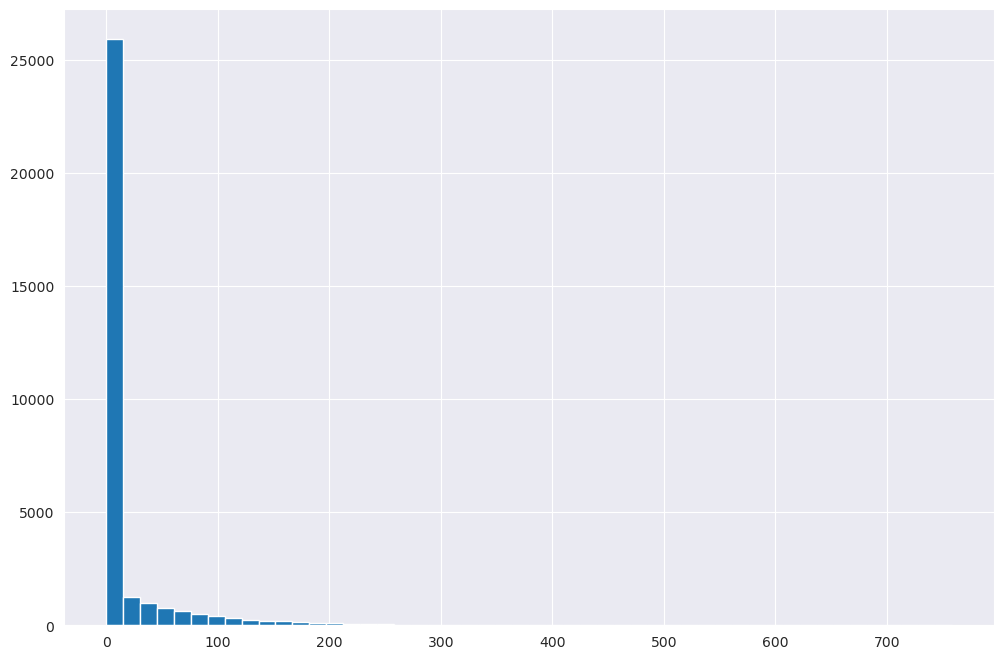

In [25]:
plt.figure(figsize = (12,8))
plt.hist(bs_call_di_mc_dists[4000], bins=50)
plt.show()

In [26]:
[(np.mean(v), np.sqrt(np.var(v)/nsims)) for (k,v) in bs_call_di_mc_dists.items()]

[(np.float64(8.654472559421736), np.float64(0.1718124120692316)),
 (np.float64(13.532136634019913), np.float64(0.22209830302968395)),
 (np.float64(14.872609781333495), np.float64(0.2329546571323845)),
 (np.float64(15.70384644433351), np.float64(0.2389615110300061)),
 (np.float64(16.056328200282184), np.float64(0.24772646907147852))]

In [27]:
bs_call_di_hull(S0, K, H, sigma, t, r)

np.float64(16.764638772868814)

These results indicate what we'd expect from theory: a discretely monitored knock-in barrier option is going to be less valuable than a continuously monitored one, and more dense monitoring increases value monotonically. For a fixed path, making the monitoring lattice more dense (in the subset order) is going to strictly increase the opportunities for the option to knock in, which also increases its value. Making the lattice more dense by interval width does not give a monotonic relationship for a single path, but does for the full space of paths.

In [28]:
bs_call(S0,K,sigma,t,r)

np.float64(43.39466062140856)

# Things to try
1. Try continuous -> discrete correction [x]
2. Compare against value of vanilla option as barrier approaches strike [x]
3. Compute delta [x]
4. Show limit value for knock-in as maturity -> infinity [x]
5. Mention in-out parity
6. Implement hedging, compare behavior near barrier vs far
7. Compute delta for spot & maturity, not just spot [x]

In [29]:
# cont-discrete correction (https://www.columbia.edu/~sk75/mfBGK.pdf)

zeta_half = -1.4603545088095868128895
beta = -zeta_half/np.sqrt(2*np.pi)

def bs_call_di_corrected(S0, K, H, sigma, t, r, m_steps):
    # s = np.sign(H-S0)
    s = -1
    H_corr = np.exp(s * beta * sigma * np.sqrt(t/m_steps)) * H
    return bs_call_di_hull(S0, K, H_corr, sigma, t, r)

def bs_call_di_corrected_delta(S0, K, H, sigma, t, r, m_steps):
    # s = np.sign(H-S0)
    s = -1
    H_corr = np.exp(s * beta * sigma * np.sqrt(t/m_steps)) * H
    return bs_call_di_hull_delta(S0, K, H_corr, sigma, t, r)

def bs_call_di_corrected_gamma(S0, K, H, sigma, t, r, m_steps):
    return derivative(bs_call_di_corrected_delta, S0, args=(K,H,sigma,t,r,m_steps))

def bs_call_di_corrected_vega(S0, K, H, sigma, t, r, m_steps):
    return derivative(
        lambda s, S0, K, H, t, r, m_steps: bs_call_di_corrected(S0, K, H, s, t, r, m_steps),
        sigma,
        args=(S0,K,H,t,r,m_steps)
    )

naive_di_value = bs_call_di_hull(S0,K,H,sigma,t,r)
corrected_di_values = {m_steps: bs_call_di_corrected(S0,K,H,sigma,t,r,m_steps) for m_steps in nsteps}

naive_ratios = {m_steps: np.mean(bs_call_di_mc_dists[m_steps])/naive_di_value for m_steps in nsteps}
corrected_ratios = {m_steps: np.mean(bs_call_di_mc_dists[m_steps])/corrected_di_values[m_steps] for m_steps in nsteps}

(naive_ratios, corrected_ratios)

({10: np.float64(0.5162337630219489),
  100: np.float64(0.8071833110964344),
  252: np.float64(0.8871416785551444),
  1000: np.float64(0.9367244148289049),
  4000: np.float64(0.9577497265415029)},
 {10: np.float64(1.0062609478823996),
  100: np.float64(0.9869535520151939),
  252: np.float64(1.005875464832742),
  1000: np.float64(0.9972465891877937),
  4000: np.float64(0.9880951436349122)})

After applying the continuous-discrete correction, the result improves substantially. Since the deviation from the true result under BS assumptions behaves as o(1/sqrt(m)), then we expect the correction to get better as the total number of monitoring points increases.

# Random notes to organize later

Delta at the barrier is very vicious and makes it hard to hedge accurately.

The main place where you'd want to use barrier options is with FX.

Deriving the value of a barrier option can proceed via the method of images and the reflection principle.

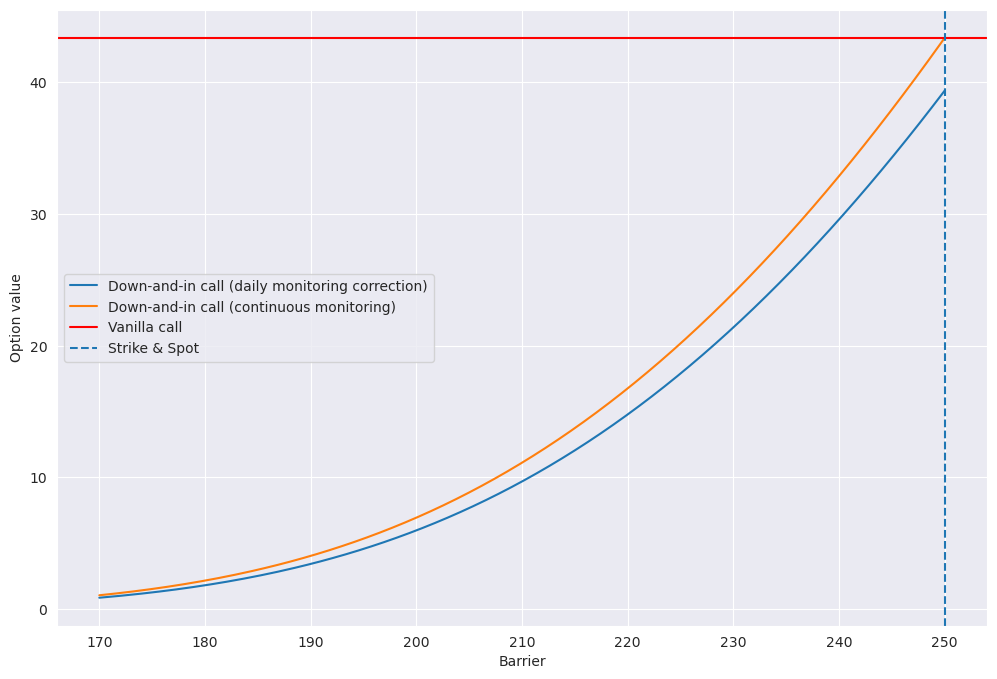

In [12]:
# Call value with varying barrier

S0 = 250
K = 250
m_steps = 252
Hs = np.linspace(170, 250, 200)
vanilla_value = bs_call(S0, K, sigma, t, r)
corrected_barrier_values = [bs_call_di_corrected(S0, K, H, sigma, t, r, m_steps) for H in Hs]
naive_barrier_values = [bs_call_di_hull(S0, K, H, sigma, t, r) for H in Hs]
plt.figure(figsize=(12,8))
plt.plot(Hs, corrected_barrier_values, label='Down-and-in call (daily monitoring correction)')
plt.plot(Hs, naive_barrier_values, label='Down-and-in call (continuous monitoring)')
plt.axhline(y=vanilla_value, label='Vanilla call', color='red')
plt.axvline(x=K, label='Strike & Spot', ls='--')
plt.xlabel('Barrier')
plt.ylabel('Option value')
plt.legend()
plt.show()

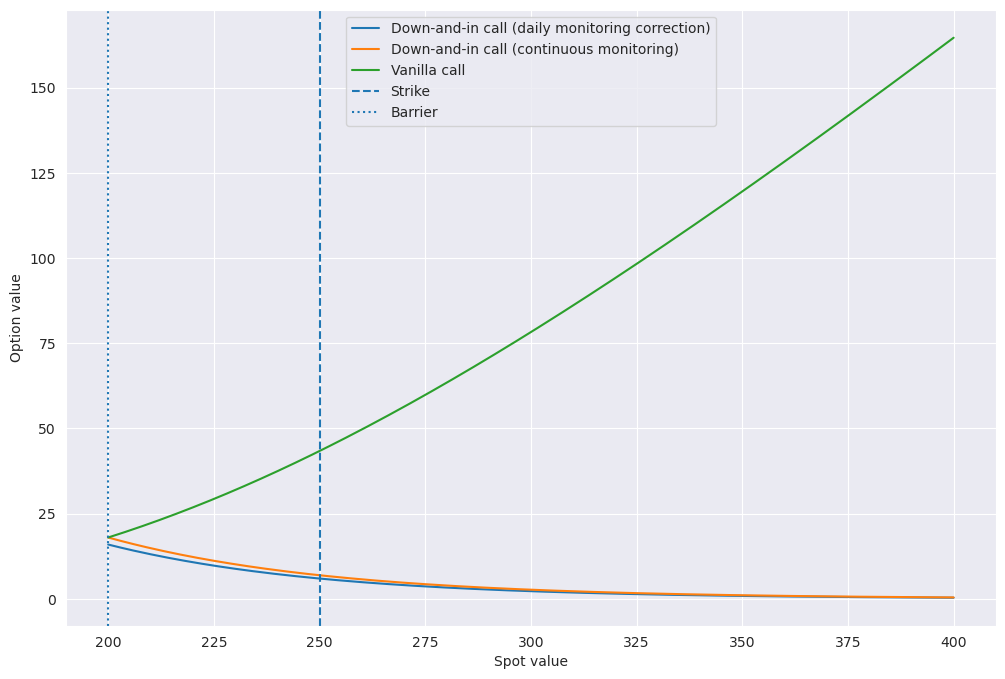

In [13]:
# Call value with varying spot

S0s = np.linspace(200,400,200)
K = 250
m_steps = 252
H = 200
vanilla_values = [bs_call(S0,K,sigma,t,r) for S0 in S0s]
corrected_barrier_values = [bs_call_di_corrected(S0, K, H, sigma, t, r, m_steps) for S0 in S0s]
naive_barrier_values = [bs_call_di_hull(S0, K, H, sigma, t, r) for S0 in S0s]
plt.figure(figsize=(12,8))
plt.plot(S0s, corrected_barrier_values, label='Down-and-in call (daily monitoring correction)')
plt.plot(S0s, naive_barrier_values, label='Down-and-in call (continuous monitoring)')
plt.plot(S0s, vanilla_values, label='Vanilla call')
plt.xlabel('Spot value')
plt.ylabel('Option value')
plt.axvline(x=K, label='Strike', ls='--')
plt.axvline(x=H, label='Barrier', ls=':')
plt.legend()
plt.show()

I figure that the discontinuity at $H = S_0$ of the corrected down-in call value is a natural feature and not an artifact. Imagining the case of $r=0$, and only a very small number of monitoring points (which should not change the qualitative continuity behavior), if $S_0 = H - \varepsilon$ for some $\varepsilon > 0$, then the initial monitoring point fails, and the underlying will be about as likely to terminate above $H$ as below at the next monitoring point, so we have substantial mass contributed to the final value by cases which might never knock in. By contrast, if $S_0 \geq H$, we knock in immediately and lose all that mass contributed by eventual failures in one go.

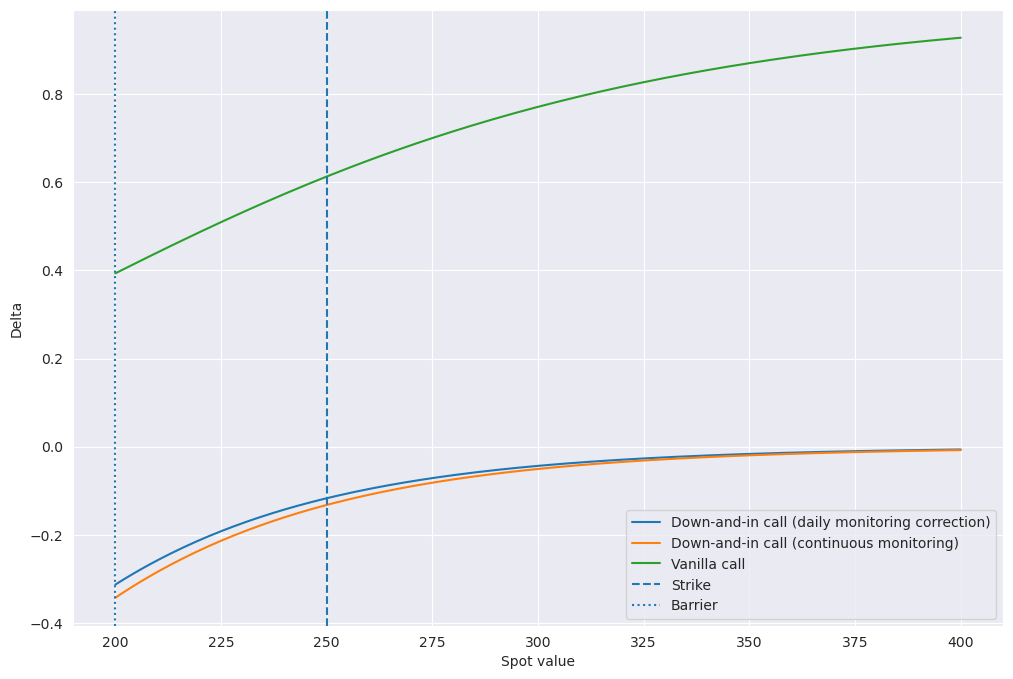

In [14]:
# Delta with varying spot

S0s = np.linspace(200,400,200)
K = 250
t = 1
m_steps = 252*t
H = 200
vanilla_deltas = np.array([bs_call_delta(S0,K,sigma,t,r) for S0 in S0s])
corrected_barrier_deltas = np.array([bs_call_di_corrected_delta(S0, K, H, sigma, t, r, m_steps) for S0 in S0s])
naive_barrier_deltas = np.array([bs_call_di_hull_delta(S0, K, H, sigma, t, r) for S0 in S0s])
plt.figure(figsize=(12,8))
plt.plot(S0s, corrected_barrier_deltas, label='Down-and-in call (daily monitoring correction)')
plt.plot(S0s, naive_barrier_deltas, label='Down-and-in call (continuous monitoring)')
plt.plot(S0s, vanilla_deltas, label='Vanilla call')
# plt.plot(S0s, vanilla_deltas - corrected_barrier_deltas, label = 'Down-and-out call (daily monitoring correction)')
plt.xlabel('Spot value')
plt.ylabel('Delta')
plt.axvline(x=K, label='Strike', ls='--')
plt.axvline(x=H, label='Barrier', ls=':')
plt.legend()
plt.show()

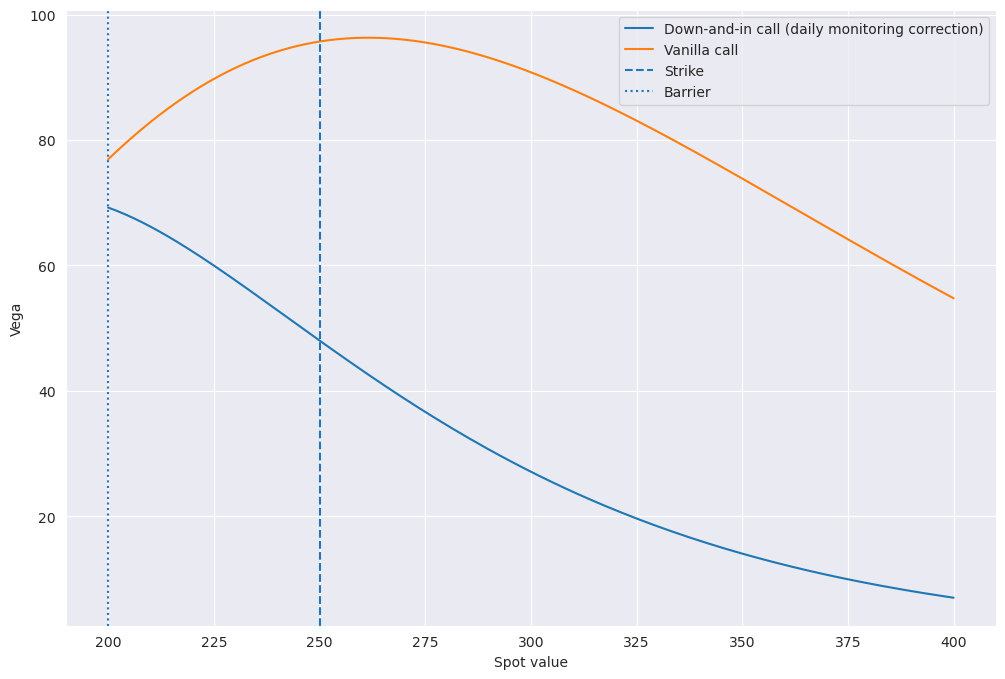

In [15]:
# Vega with varying spot

S0s = np.linspace(200,400,200)
K = 250
t = 1
m_steps = 252*t
H = 200
vanilla_vegas = np.array([bs_vega(S0,K,sigma,t,r) for S0 in S0s])
corrected_barrier_vegas = np.array([bs_call_di_corrected_vega(S0, K, H, sigma, t, r, m_steps).df for S0 in S0s])
plt.figure(figsize=(12,8))
plt.plot(S0s, corrected_barrier_vegas, label='Down-and-in call (daily monitoring correction)')
plt.plot(S0s, vanilla_vegas, label='Vanilla call')
# plt.plot(S0s, vanilla_deltas - corrected_barrier_deltas, label = 'Down-and-out call (daily monitoring correction)')
plt.xlabel('Spot value')
plt.ylabel('Vega')
plt.axvline(x=K, label='Strike', ls='--')
plt.axvline(x=H, label='Barrier', ls=':')
plt.legend()
plt.show()

Regarding vega: it's strange to me that vega for the down-in option is bounded below the vanilla vega. Among other things this implies that vega for down-out is also positive near the barrier! Other than that, I'm not sure how to interpret the significance of this graph. Fiddling with K reveals that for K=200+epsilon, this bound condition is no longer true everywhere, so it doesn't appear to be a generic property.

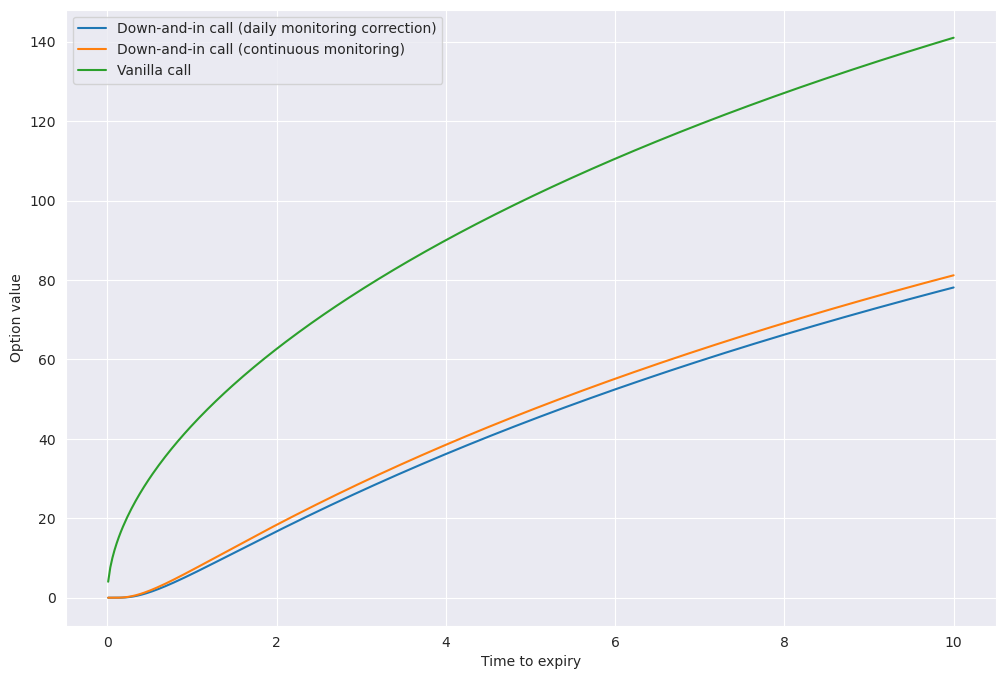

In [16]:
# Value with varying maturity
# Note: correction worse at small t

S0 = 250
K = 250
m_steps = 252
H = 200
ts = np.linspace(0.01,10,401)
vanilla_values = np.array([bs_call(S0,K,sigma,t,r) for t in ts])
corrected_barrier_values = np.array([bs_call_di_corrected(S0, K, H, sigma, t, r, m_steps*t) for t in ts])
naive_barrier_values = np.array([bs_call_di_hull(S0, K, H, sigma, t, r) for t in ts])
plt.figure(figsize=(12,8))
plt.plot(ts, corrected_barrier_values, label='Down-and-in call (daily monitoring correction)')
plt.plot(ts, naive_barrier_values, label='Down-and-in call (continuous monitoring)')
plt.plot(ts, vanilla_values, label='Vanilla call')
# plt.plot(S0s, vanilla_deltas - corrected_barrier_deltas, label = 'Down-and-out call (daily monitoring correction)')
plt.xlabel('Time to expiry')
plt.ylabel('Option value')
plt.legend()
plt.show()

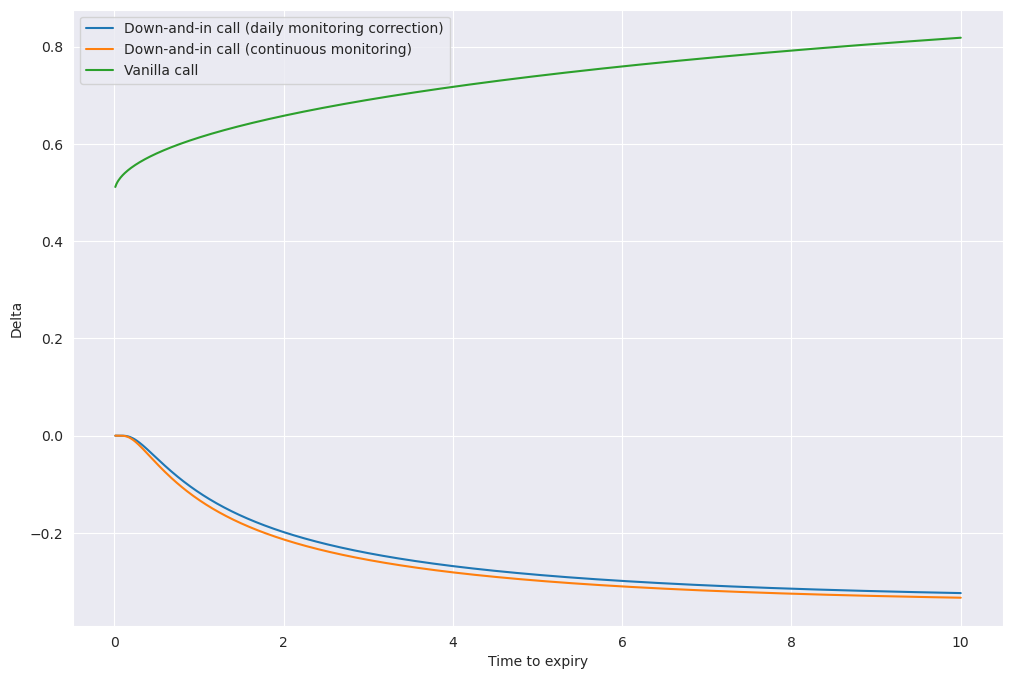

In [17]:
# Delta with varying maturity

S0s = 250
K = 250
m_steps = 252
H = 200
ts = np.linspace(0.01,10,801)
vanilla_deltas = np.array([bs_call_delta(S0,K,sigma,t,r) for t in ts])
corrected_barrier_deltas = np.array([bs_call_di_corrected_delta(S0, K, H, sigma, t, r, m_steps*t) for t in ts])
naive_barrier_deltas = np.array([bs_call_di_hull_delta(S0, K, H, sigma, t, r) for t in ts])
plt.figure(figsize=(12,8))
plt.plot(ts, corrected_barrier_deltas, label='Down-and-in call (daily monitoring correction)')
plt.plot(ts, naive_barrier_deltas, label='Down-and-in call (continuous monitoring)')
plt.plot(ts, vanilla_deltas, label='Vanilla call')
# plt.plot(S0s, vanilla_deltas - corrected_barrier_deltas, label = 'Down-and-out call (daily monitoring correction)')
plt.xlabel('Time to expiry')
plt.ylabel('Delta')
plt.legend()
plt.show()

The value and delta going to zero as $t \to 0$ is not surprising. Since the spot is a fixed distance above the barrier, and we haven't knocked in yet, then the stock needs to make a very wild oscillation to hit the barrier in an infinitesimal time. This is vanishingly unlikely, so the stock's value would be zero. Moreover, perturbing the spot value doesn't change that fact, so delta also goes to zero as time goes to zero. (This is very handwavey - you can't generally go from f being near zero to f' being near zero, but you can if you have enough regularity, and the Black-Scholes PDE probably gives enough regularity.)

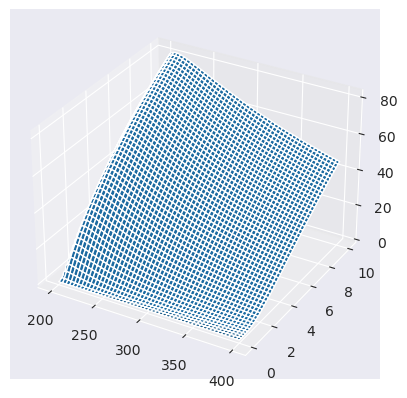

In [18]:
# Value against varying spot and maturity
S0s = np.linspace(200, 400, 300)
K = 250
m_steps = 252
H = 200
ts = np.linspace(0.01, 10, 300)
xs, ys = np.meshgrid(S0s, ts)
cbv = bs_call_di_corrected(xs, K, H, sigma, ys, r, m_steps*ts)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(xs, ys, cbv)
plt.show()

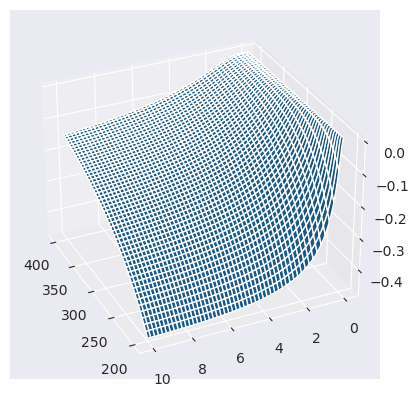

In [19]:
# Delta against varying spot and maturity
S0s = np.linspace(200, 400, 200)
K = 250
m_steps = 252
H = 200
ts = np.linspace(0.001, 10, 200)
xs, ys = np.meshgrid(S0s, ts)
cbv = bs_call_di_corrected_delta(xs, K, H, sigma, ys, r, m_steps*ys)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.view_init(azim=155, elev=30)
ax.plot_surface(xs, ys, cbv)
plt.show()

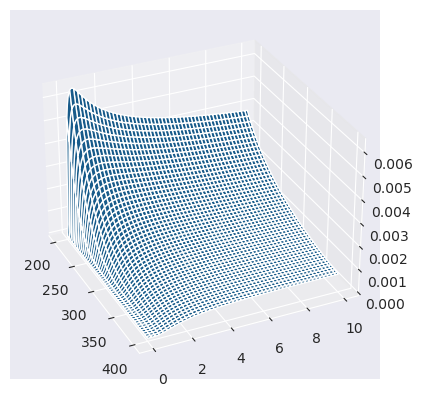

In [21]:
# Plot of gamma against varying spot and maturity
S0s = np.linspace(200, 400, 200)
K = 250
m_steps = 252
H = 200
ts = np.linspace(0.001, 10, 200)
xs, ys = np.meshgrid(S0s, ts)
cbv = bs_call_di_corrected_gamma(xs, K, H, sigma, ys, r, m_steps*ys)


fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.view_init(azim=-25, elev=30)
ax.plot_surface(xs, ys, cbv.df)
plt.show()

In [302]:
# Trying out delta hedging
S0 = 250
sigma = .4
mu = .08
t = 1
r = .035
n_sims = 2
n_steps = 252*t
dt = 1/252
H = 200

stock_paths = GBM_paths(S0, sigma, t, r, mu, n_sims, n_steps)
index_of_ki = np.argmax(stock_paths <= H, axis=1)
index_of_ki = np.where(index_of_ki == 0, n_steps+1, index_of_ki)

times = np.linspace(0,t,n_steps+1)
times[-1] -= dt/50 # avoid division by zero in calculating call_di delta
deltas = np.zeros_like(stock_paths)

for i in range(n_sims):
    kix = index_of_ki[i]
    deltas[i,:kix] = bs_call_di_corrected_delta(stock_paths[i,:kix], K, H, sigma, (t-times)[:kix], r, n_steps)
    if kix < len(deltas[i]):
        deltas[i,kix:] = bs_call_delta(stock_paths[i,kix:], K, sigma, (t-times)[kix:], r)

discounted_stock_paths = np.exp(-r*times) * stock_paths
discounted_stock_moves = discounted_stock_paths[:, 1:] - discounted_stock_paths[:, :-1]
profit_from_holding = np.sum(deltas[:, :-1] * discounted_stock_moves, axis=1)

final_stock = stock_paths[:, -1]
knocked_in = index_of_ki <= n_steps
payoff = np.where(knocked_in, np.maximum(final_stock - K, 0), 0)
discounted_payoff = np.exp(-r*t) * payoff

initial_option_price = bs_call_di_corrected(S0, K, H, sigma, t, r, n_steps)
hedged_pnl = initial_option_price + profit_from_holding - discounted_payoff

unhedged_pnl = initial_option_price - discounted_payoff

(unhedged_pnl, hedged_pnl)

(array([-64.79276978,   5.97837346]), array([-2.74139544,  0.55000878]))